# 01 — Data Preparation & Spectrogram Generation
**Project**: Defect Detection in Gear & Bearing using Deep Learning

This notebook handles the complete data pipeline:
1. Download the CWRU Bearing and Gearbox Fault datasets via Kaggle API
2. Explore and visualize the raw vibration signals
3. Convert vibration time-series → STFT spectrograms
4. Organize spectrograms into train/val/test splits for ImageFolder loading

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import stft
from PIL import Image
import shutil
import warnings
warnings.filterwarnings('ignore')

# Configuration
SEGMENT_LENGTH = 1024
STFT_NPERSEG = 256
STFT_NOVERLAP = 128
SAMPLING_RATE = 48000
SAMPLES_PER_CLASS = 300

BASE_DIR = os.path.abspath('..')
RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
SPEC_DIR = os.path.join(BASE_DIR, 'data', 'spectrograms')
DATA_DIR = os.path.join(BASE_DIR, 'data')

print(f'Base directory: {BASE_DIR}')
print('Libraries loaded successfully.')

Base directory: C:\Users\OM GIRI\Downloads\AI-ML Project (6th sem)\Defect Detection in Gear & Bearing
Libraries loaded successfully.


## Step 1: Download Datasets via Kaggle API
We use two benchmark datasets:
- **CWRU Bearing Dataset**: Vibration signals from bearings with artificially induced faults
- **Gearbox Fault Dataset**: Vibration data from healthy and broken-tooth gearboxes

In [2]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
print('Kaggle API authenticated.')

# Download CWRU Bearing Dataset
cwru_dir = os.path.join(RAW_DIR, 'cwru')
os.makedirs(cwru_dir, exist_ok=True)
if len([f for f in os.listdir(cwru_dir) if not f.startswith('.')]) < 2:
    print('Downloading CWRU Bearing Dataset...')
    api.dataset_download_files('brjapon/cwru-bearing-datasets', path=cwru_dir, unzip=True)
    print('  Done!')
else:
    print(f'CWRU dataset already present in {cwru_dir}')

# Download Gearbox Fault Dataset
gear_dir = os.path.join(RAW_DIR, 'gearbox')
os.makedirs(gear_dir, exist_ok=True)
if len([f for f in os.listdir(gear_dir) if not f.startswith('.')]) < 2:
    print('Downloading Gearbox Fault Dataset...')
    api.dataset_download_files('brjapon/gearbox-fault-diagnosis', path=gear_dir, unzip=True)
    print('  Done!')
else:
    print(f'Gearbox dataset already present in {gear_dir}')

# Show what we have
mat_dir = os.path.join(cwru_dir, 'raw')
mat_files = [f for f in os.listdir(mat_dir) if f.endswith('.mat')]
print(f'\nCWRU .mat files: {len(mat_files)}')
for f in sorted(mat_files):
    print(f'  {f}')

print(f'\nGearbox conditions:')
for cond in ['Healthy', 'BrokenTooth']:
    cdir = os.path.join(gear_dir, cond)
    if os.path.exists(cdir):
        print(f'  {cond}: {len(os.listdir(cdir))} files')

Kaggle API authenticated.
CWRU dataset already present in C:\Users\OM GIRI\Downloads\AI-ML Project (6th sem)\Defect Detection in Gear & Bearing\data\raw\cwru
Gearbox dataset already present in C:\Users\OM GIRI\Downloads\AI-ML Project (6th sem)\Defect Detection in Gear & Bearing\data\raw\gearbox

CWRU .mat files: 10
  B007_1_123.mat
  B014_1_190.mat
  B021_1_227.mat
  IR007_1_110.mat
  IR014_1_175.mat
  IR021_1_214.mat
  OR007_6_1_136.mat
  OR014_6_1_202.mat
  OR021_6_1_239.mat
  Time_Normal_1_098.mat

Gearbox conditions:
  Healthy: 10 files
  BrokenTooth: 10 files


## Step 2: Explore Raw Vibration Signals
Let's visualize what the raw vibration data looks like for different fault types.

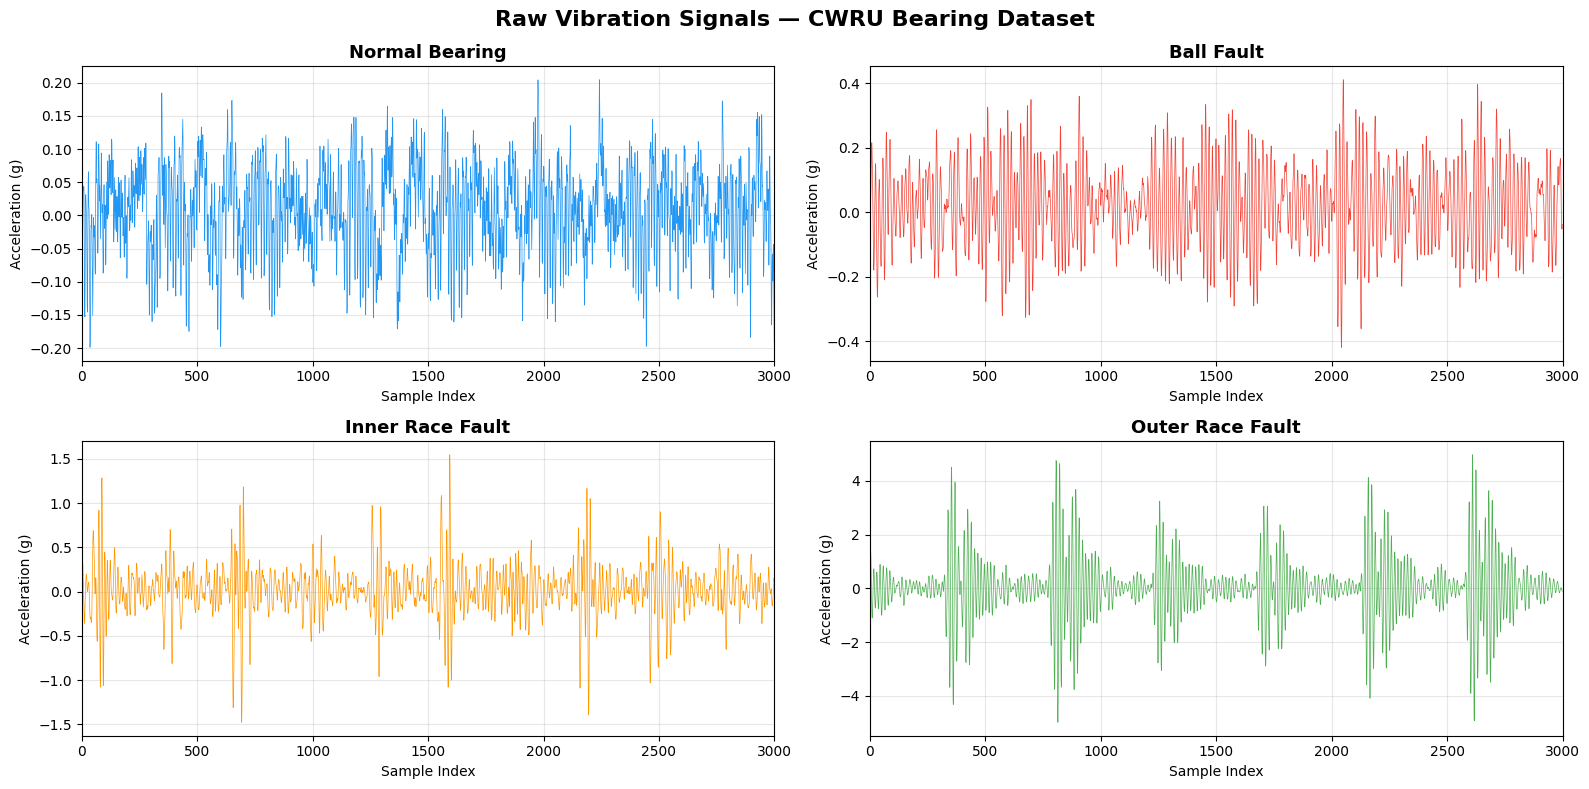

Raw vibration signals visualized for all 4 bearing conditions.


In [3]:
mat_dir = os.path.join(RAW_DIR, 'cwru', 'raw')

# Load samples from each fault type
fault_files = {
    'Normal Bearing': 'Time_Normal_1_098.mat',
    'Ball Fault': 'B007_1_123.mat',
    'Inner Race Fault': 'IR007_1_110.mat',
    'Outer Race Fault': 'OR007_6_1_136.mat',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Raw Vibration Signals — CWRU Bearing Dataset', fontsize=16, fontweight='bold')

colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']

for idx, (fault_name, filename) in enumerate(fault_files.items()):
    filepath = os.path.join(mat_dir, filename)
    mat_data = loadmat(filepath)
    
    # Find the drive-end accelerometer key
    de_key = [k for k in mat_data.keys() if 'DE_time' in k][0]
    signal = mat_data[de_key].flatten()
    
    row, col = idx // 2, idx % 2
    axes[row][col].plot(signal[:3000], color=colors[idx], linewidth=0.5)
    axes[row][col].set_title(fault_name, fontsize=13, fontweight='bold')
    axes[row][col].set_xlabel('Sample Index')
    axes[row][col].set_ylabel('Acceleration (g)')
    axes[row][col].grid(True, alpha=0.3)
    axes[row][col].set_xlim(0, 3000)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'raw_vibration_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Raw vibration signals visualized for all 4 bearing conditions.')

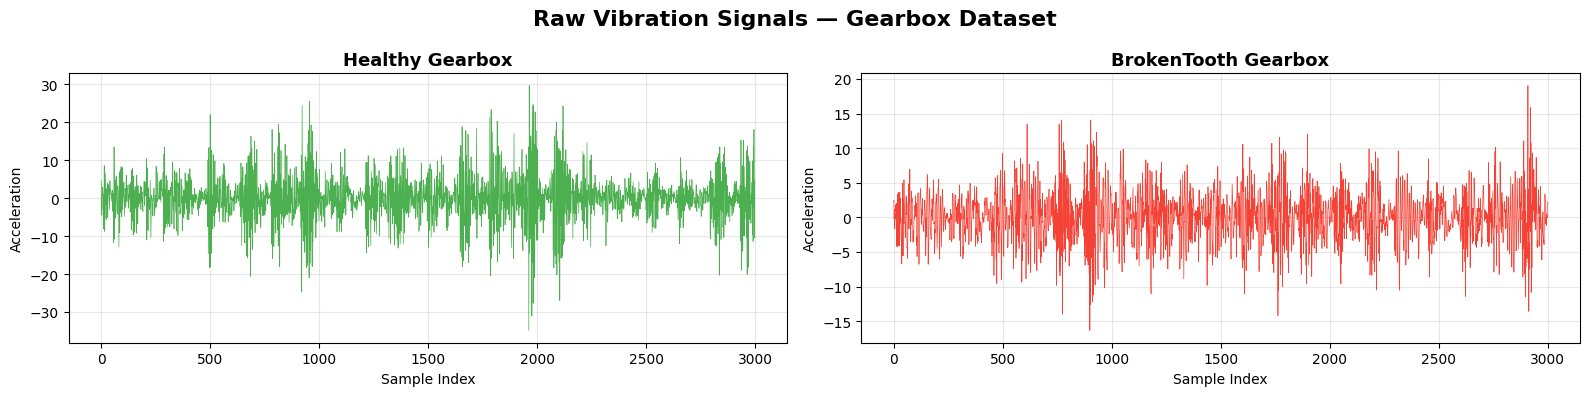

Gearbox vibration signals visualized.


In [4]:
import pandas as pd

# Visualize gearbox vibration signals
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Raw Vibration Signals — Gearbox Dataset', fontsize=16, fontweight='bold')

for idx, (cond, color) in enumerate([('Healthy', '#4CAF50'), ('BrokenTooth', '#F44336')]):
    cdir = os.path.join(RAW_DIR, 'gearbox', cond)
    files = sorted(os.listdir(cdir))
    df = pd.read_csv(os.path.join(cdir, files[0]))
    signal = df['a1'].values
    
    axes[idx].plot(signal[:3000], color=color, linewidth=0.5)
    axes[idx].set_title(f'{cond} Gearbox', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Acceleration')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'raw_gearbox_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Gearbox vibration signals visualized.')

## Step 3: Signal → Spectrogram Conversion (STFT)
The core innovation: we transform 1D vibration signals into 2D time-frequency images.

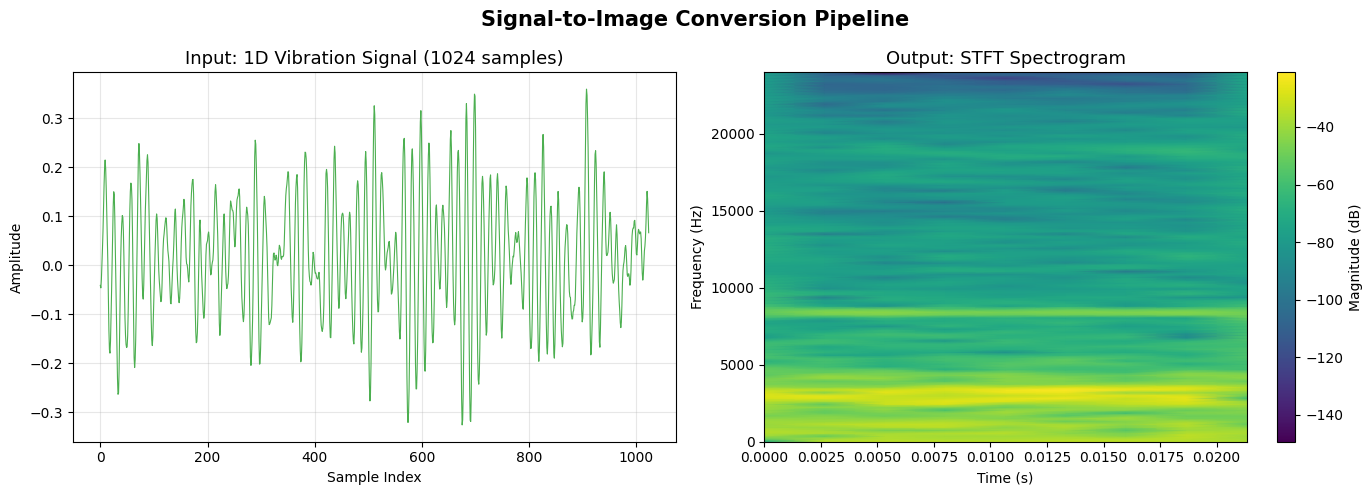

STFT conversion demonstrated: 1D signal → 2D spectrogram


In [5]:
def signal_to_spectrogram(signal_segment, sr=SAMPLING_RATE):
    """Convert a 1D vibration segment into a 2D STFT spectrogram."""
    frequencies, times, Zxx = stft(
        signal_segment, fs=sr,
        nperseg=STFT_NPERSEG, noverlap=STFT_NOVERLAP, nfft=STFT_NPERSEG
    )
    magnitude = np.abs(Zxx)
    magnitude_db = 20 * np.log10(magnitude + 1e-10)
    return frequencies, times, magnitude_db


# Demonstrate the conversion on a sample segment
filepath = os.path.join(mat_dir, 'B007_1_123.mat')
mat_data = loadmat(filepath)
de_key = [k for k in mat_data.keys() if 'DE_time' in k][0]
signal = mat_data[de_key].flatten()
segment = signal[:SEGMENT_LENGTH]

freqs, times, spec = signal_to_spectrogram(segment)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(segment, color='#4CAF50', linewidth=0.8)
axes[0].set_title('Input: 1D Vibration Signal (1024 samples)', fontsize=13)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

im = axes[1].pcolormesh(times, freqs, spec, cmap='viridis', shading='gouraud')
axes[1].set_title('Output: STFT Spectrogram', fontsize=13)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')
plt.colorbar(im, ax=axes[1], label='Magnitude (dB)')

plt.suptitle('Signal-to-Image Conversion Pipeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'stft_demo.png'), dpi=150, bbox_inches='tight')
plt.show()
print('STFT conversion demonstrated: 1D signal → 2D spectrogram')

## Step 4: Generate Spectrograms for All Classes
We process all raw signals and generate 300 spectrograms per class.

In [6]:
# Check if spectrograms already exist
if os.path.exists(SPEC_DIR) and len(os.listdir(SPEC_DIR)) >= 6:
    total = sum(len([f for f in os.listdir(os.path.join(SPEC_DIR, c)) if f.endswith('.png')])
               for c in os.listdir(SPEC_DIR) if os.path.isdir(os.path.join(SPEC_DIR, c)))
    print(f'Spectrograms already generated: {total} images in {SPEC_DIR}')
    print('Skipping regeneration. Delete the spectrograms folder to regenerate.')
else:
    print('Generating spectrograms... (this may take a few minutes)')
    %run ../scripts/generate_spectrograms.py

Spectrograms already generated: 1800 images in C:\Users\OM GIRI\Downloads\AI-ML Project (6th sem)\Defect Detection in Gear & Bearing\data\spectrograms
Skipping regeneration. Delete the spectrograms folder to regenerate.


## Step 5: Visualize Sample Spectrograms per Class

Classes found: ['ball_fault', 'broken_tooth', 'healthy_gear', 'inner_race_fault', 'normal_bearing', 'outer_race_fault']


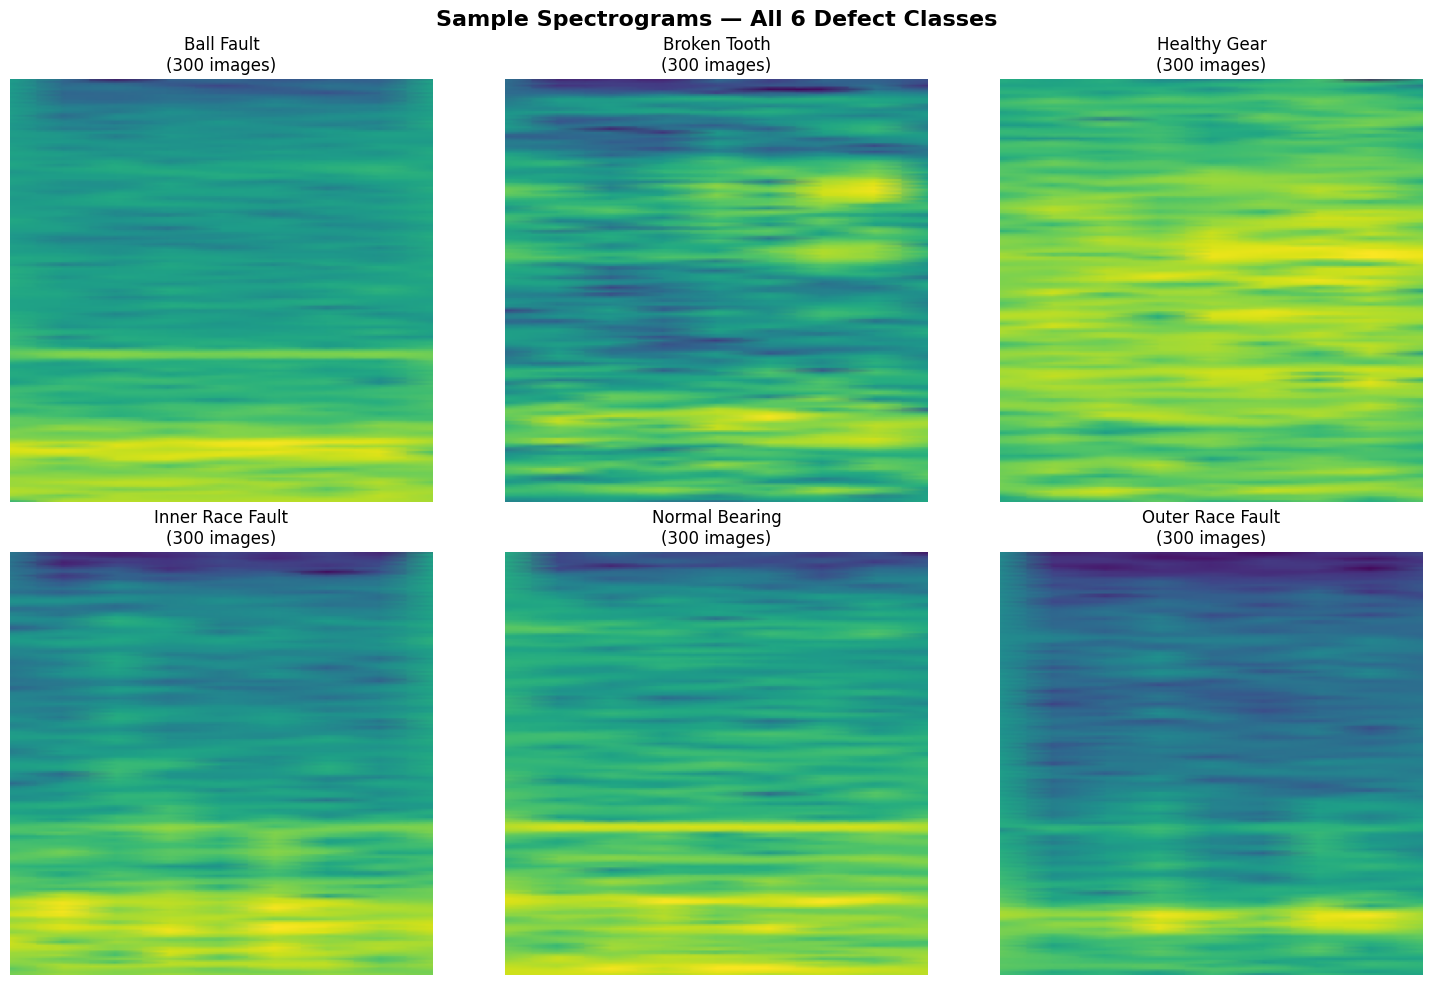

Sample spectrograms visualized for all 6 classes.


In [7]:
classes = sorted([d for d in os.listdir(SPEC_DIR) if os.path.isdir(os.path.join(SPEC_DIR, d))])
print(f'Classes found: {classes}')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Sample Spectrograms — All 6 Defect Classes', fontsize=16, fontweight='bold')

for idx, cls in enumerate(classes):
    row, col = idx // 3, idx % 3
    cls_dir = os.path.join(SPEC_DIR, cls)
    imgs = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])
    img = Image.open(os.path.join(cls_dir, imgs[0]))
    axes[row][col].imshow(img)
    count = len(imgs)
    axes[row][col].set_title(f'{cls.replace("_", " ").title()}\n({count} images)', fontsize=12)
    axes[row][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'data', 'sample_spectrograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Sample spectrograms visualized for all 6 classes.')

## Step 6: Dataset Split Verification

In [8]:
# Verify train/val/test splits exist
print(f'{"Class":20s} {"Train":>8s} {"Val":>8s} {"Test":>8s} {"Total":>8s}')
print('-' * 55)

grand_total = {'train': 0, 'validation': 0, 'test': 0}

for cls in classes:
    counts = {}
    for split in ['train', 'validation', 'test']:
        split_cls_dir = os.path.join(DATA_DIR, split, cls)
        if os.path.exists(split_cls_dir):
            n = len([f for f in os.listdir(split_cls_dir) if f.endswith('.png')])
        else:
            n = 0
        counts[split] = n
        grand_total[split] += n
    total = sum(counts.values())
    print(f'{cls:20s} {counts["train"]:8d} {counts["validation"]:8d} {counts["test"]:8d} {total:8d}')

print('-' * 55)
gt = sum(grand_total.values())
print(f'{"TOTAL":20s} {grand_total["train"]:8d} {grand_total["validation"]:8d} {grand_total["test"]:8d} {gt:8d}')
print(f'\nSplit ratios: Train {grand_total["train"]/gt:.0%} / Val {grand_total["validation"]/gt:.0%} / Test {grand_total["test"]/gt:.0%}')

Class                   Train      Val     Test    Total
-------------------------------------------------------
ball_fault                210       45       45      300
broken_tooth              210       45       45      300
healthy_gear              210       45       45      300
inner_race_fault          210       45       45      300
normal_bearing            210       45       45      300
outer_race_fault          210       45       45      300
-------------------------------------------------------
TOTAL                    1260      270      270     1800

Split ratios: Train 70% / Val 15% / Test 15%


## Summary
- Downloaded CWRU Bearing + Gearbox Fault datasets from Kaggle
- Converted 1D vibration signals → 2D STFT spectrograms (224×224 PNG)
- Generated 1,800 balanced spectrogram images (300 per class)
- Split into train (70%) / validation (15%) / test (15%)

**Next**: `02_Model_Training_and_Validation.ipynb` — Train ResNet-50 on these spectrograms.